In [1]:
import os
import glob
import pandas as pd
from osgeo import gdal, osr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import xarray as xr
import copy

In [2]:
dataDir = '/wp_data/sites/Degero/Sentinel'
timestep = '*2023-08.tif'

bd = 0 

In [3]:
dataDir = '/wp_data/sites/HatfieldThorne/Sentinel'
timestep = '*2021-01.tif'


bd = 1 

In [4]:
pattern = os.path.join(dataDir,'MSIL2A' ,'datacube' ,'S2_SR', 'B8',timestep)
matching_files = glob.glob(pattern)

for fname in matching_files:
    print(fname)

/wp_data/sites/HatfieldThorne/Sentinel/MSIL2A/datacube/S2_SR/B8/S2_SR_B08_2021-01.tif


Text(0.5, 1.0, 'B8')

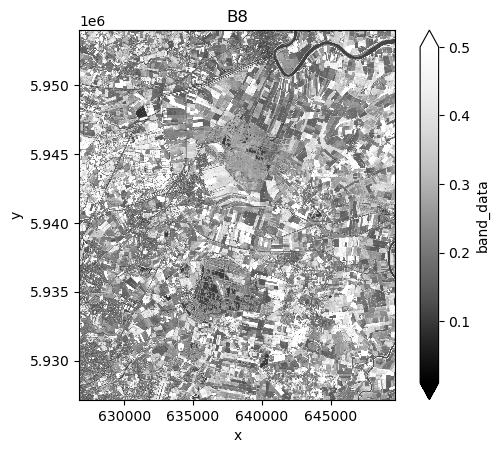

In [5]:
b8 = xr.open_dataset(fname)
# Band 1 - 2023-08-06 10:05:59
b8 = b8.band_data[bd] / 10000.0  # in xarrays index starts at 0 

fig_01, ax = plt.subplots()
ax = b8.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5)
ax.axes.set_aspect('equal')
ax.axes.set_title('B8')

In [6]:
pattern = os.path.join(dataDir,'MSIL1C' ,'datacube', 'S2_TOA' ,'cprob', timestep)
matching_files = glob.glob(pattern)

for fname in matching_files:
    print(fname)

/wp_data/sites/HatfieldThorne/Sentinel/MSIL1C/datacube/S2_TOA/cprob/S2_TOA_ACM_2021-01.tif


Text(0.5, 1.0, 'cloud_probability')

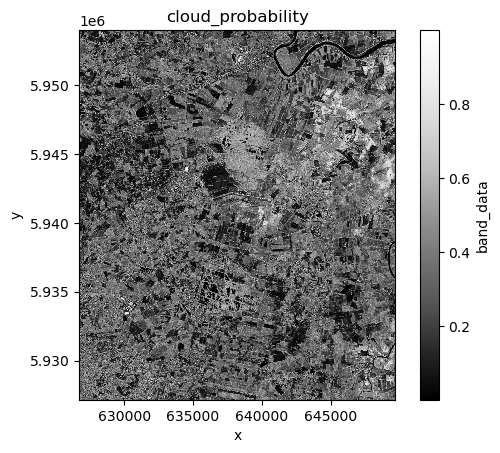

In [7]:
cloud_probability = xr.open_dataset(fname)
# Band 1 - 2023-08-06 10:05:59
cloud_probability = cloud_probability.band_data[bd]

fig_01, bx = plt.subplots()
bx = cloud_probability.plot.imshow(cmap='Greys_r')
bx.axes.set_aspect('equal')
bx.axes.set_title('cloud_probability')

In [8]:
BUFFER=70
CLD_PRB_THRESH=0.45
CLD_PRJ_DIST=2
NIR_DRK_THRESH=0.15
maxDis = 150

Text(0.5, 1.0, 'is_cloud')

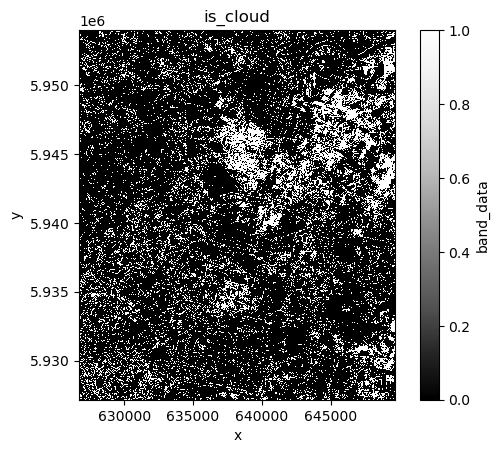

In [9]:
is_cloud = (cloud_probability>CLD_PRB_THRESH).astype(bool)

fig_03, cx = plt.subplots()

cx = is_cloud.plot.imshow(cmap='Greys_r')
cx.axes.set_aspect('equal')
cx.axes.set_title('is_cloud')

Text(0.5, 1.0, 'dark pixels')

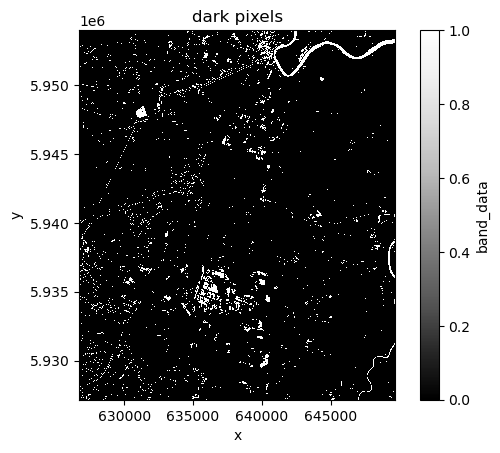

In [10]:
dark_pixels = (b8<NIR_DRK_THRESH).astype(bool)

fig_03, dx = plt.subplots()

dx = dark_pixels.plot.imshow(cmap='Greys_r')
dx.axes.set_aspect('equal')
dx.axes.set_title('dark pixels')

In [11]:
pattern = os.path.join(dataDir,'MSIL2A', 'datacube' ,'S2_SR', 'B2',timestep)
matching_files = glob.glob(pattern)

for fname in matching_files:
    print(fname)
    b2_reference = copy.deepcopy(fname)

/wp_data/sites/HatfieldThorne/Sentinel/MSIL2A/datacube/S2_SR/B2/S2_SR_B02_2021-01.tif


In [12]:
dataset = gdal.Open(fname)
band = dataset.GetRasterBand(bd+1)  # 1 is band 0 index start at 1 in gdal
metadata = band.GetMetadata()  # metadata is a dict
saa = metadata.get("saa", "No 'saa' metadata found")
saa = float(saa)

In [13]:
def directional_distance_transform(is_cloud, saa, max_distance):
    """
    Projects distances from clouds in a specific direction.

    Parameters:
    is_cloud (np.ndarray): Binary mask where clouds are marked with 1 and non-clouds with 0.
    saa (float): Solar Azimuth Angle - direction in degrees (0-360) where 0 is North.
    max_distance (int): Maximum distance to project.

    Returns:
    np.ndarray: Distance transform array.
    """
    # Convert azimuth to radians
    azimuth_rad = np.deg2rad(90-saa)
    
    # Calculate the direction vector
    dx = np.sin(azimuth_rad)
    dy = np.cos(azimuth_rad)
    
    # Initialize the distance transform array
    distance_transform = np.full(is_cloud.shape, np.inf)
    
    # Get the indices of cloud pixels
    cloud_indices = np.argwhere(is_cloud.data == 1)
    
    for y, x in cloud_indices:
        for d in range(1, max_distance + 1):
            # Calculate the new position
            new_x = int(round(x + d * dx))
            new_y = int(round(y + d * dy))
            
            # Check if the new position is within bounds
            if 0 <= new_x < is_cloud.shape[1] and 0 <= new_y < is_cloud.shape[0]:
                distance_transform[new_y, new_x] = min(distance_transform[new_y, new_x], d)
    
    # Replace inf with 0 for non-cloud areas
    distance_transform[np.isinf(distance_transform)] = 0
    
    return distance_transform

In [14]:
distance_transform = (directional_distance_transform(is_cloud, saa, maxDis)>0).astype(bool)
shadows = dark_pixels * distance_transform

Text(0.5, 1.0, 'shadows')

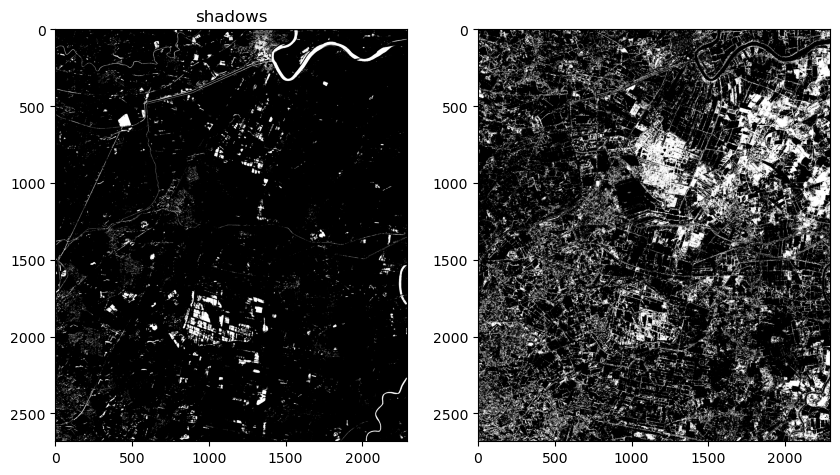

In [15]:
fig_04, (ex, fx) = plt.subplots(1,2, figsize=(10, 15))

fx.imshow(is_cloud.data, cmap='Greys_r')
fx.axes.set_aspect('equal')

ex.imshow(shadows, cmap='Greys_r')
ex.axes.set_aspect('equal')
ex.axes.set_title('shadows')

In [16]:
# set x and y as pandaIndexes in is_cloud and shadows xarray.Datarray
is_cloud = is_cloud.assign_coords(
    y=pd.Index(is_cloud['y'].values, name='y'),
    x=pd.Index(is_cloud['x'].values, name='x')
)

shadows = shadows.assign_coords(
    y=pd.Index(is_cloud['y'].values, name='y'),
    x=pd.Index(is_cloud['x'].values, name='x')
)

b8 = b8.assign_coords(
    y=pd.Index(is_cloud['y'].values, name='y'),
    x=pd.Index(is_cloud['x'].values, name='x')
)

Text(0.5, 1.0, 'cloud mask')

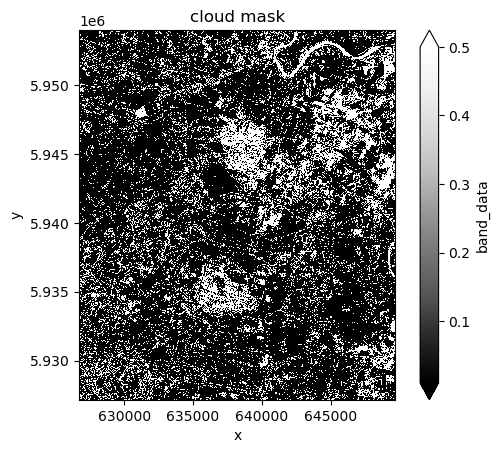

In [17]:
cloud_mask = is_cloud | shadows

cloud_mask = cloud_mask.assign_coords(
    y=pd.Index(is_cloud['y'].values, name='y'),
    x=pd.Index(is_cloud['x'].values, name='x')
)

fig_test, dx = plt.subplots()
dc = cloud_mask.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5)
dc.axes.set_aspect('equal')
dc.axes.set_title('cloud mask')

Text(0.5, 1.0, 'b8 masked with maxDis 150')

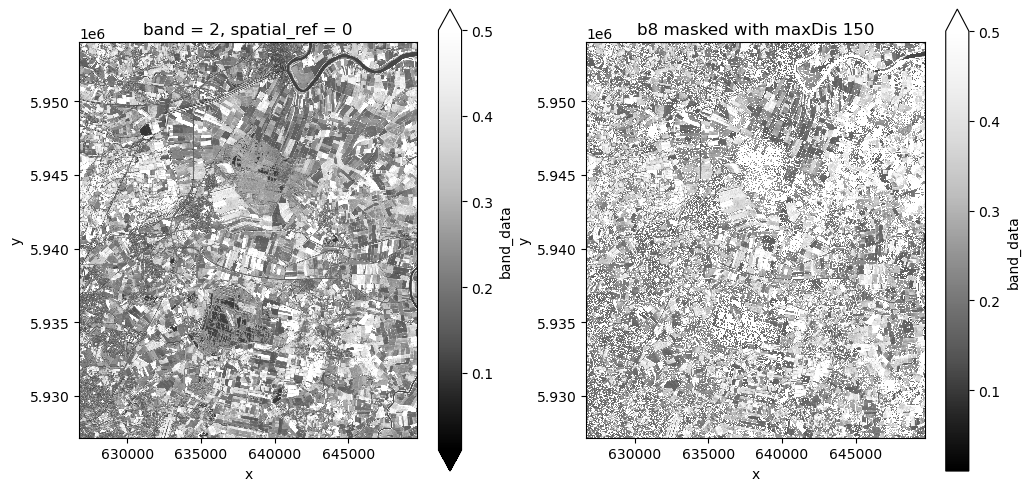

In [18]:
fig_05, (gx, hx) = plt.subplots(1,2, figsize=(12, 6))

b8.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5, ax=gx)
gx.axes.set_aspect('equal')

b8_masked = b8.where(~cloud_mask)
b8_masked.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5, ax=hx)
hx.axes.set_aspect('equal')
hx.axes.set_title(f'b8 masked with maxDis {maxDis}')

# Save the figure
# fig_05.savefig(f'b8_masked_maxDis_{maxDis}.png', dpi=300)

In [19]:
pattern = os.path.join(dataDir,'MSIL2A', 'datacube' ,'S2_SR', 'SCL',timestep)
matching_files = glob.glob(pattern)

for fname in matching_files:
    print(fname)
    
water_class = 6 

/wp_data/sites/HatfieldThorne/Sentinel/MSIL2A/datacube/S2_SR/SCL/S2_SR_SCL_2021-01.tif


In [20]:
def reproject_image(source_img, target_img, clip_shapefile=None, no_data_val=-9999):
    """
    Taken from Alex
    Function to reproject a source image onto the exact same spatial grid, so it
    has the same extent and spatial resolution as the other. It first checks to see 
    if a reprojection is needed (as they can be slow) and then performs one. It 
    is also cut to a shapefile too if needed.
    INPUTS:
         - source_img (string) - path to the image you want to manipulate.
         - target_image (string) - path to what you want source image to 
              look like.
    OPTIONS:
        - clip_shapefile (string) - the path of the shapefile you want to clip
              the data to.
        - no_data_val (int/float) - no data value to use. This will be for the 
              data outside the shapefile.
    OUTPUTS:
        - a gdal dataset. to access the data use ReadAsArray()
    """

    # get the details of the source image
    if str == type(source_img):
        s = gdal.Open(source_img)
    else:
        s = target_img

    geo_s = s.GetGeoTransform()
    s_x_size, s_y_size = s.RasterXSize, s.RasterYSize
    s_xmin = min(geo_s[0], geo_s[0] + s_x_size * geo_s[1])
    s_xmax = max(geo_s[0], geo_s[0] + s_x_size * geo_s[1])
    s_ymin = min(geo_s[3], geo_s[3] + s_y_size * geo_s[5])
    s_ymax = max(geo_s[3], geo_s[3] + s_y_size * geo_s[5])
    s_xRes, s_yRes = abs(geo_s[1]), abs(geo_s[5])

    # get the details of the target image
    if type(target_img) == str:
        t = gdal.Open(target_img)
    else:
        t = target_img
    geo_t = t.GetGeoTransform()
    x_size, y_size = t.RasterXSize, t.RasterYSize
    xmin = min(geo_t[0], geo_t[0] + x_size * geo_t[1])
    xmax = max(geo_t[0], geo_t[0] + x_size * geo_t[1])
    ymin = min(geo_t[3], geo_t[3] + y_size * geo_t[5])
    ymax = max(geo_t[3], geo_t[3] + y_size * geo_t[5])
    xRes, yRes = abs(geo_t[1]), abs(geo_t[5])

    if (s_x_size == x_size) & (s_y_size == y_size) & \
            (s_xmin == xmin) & (s_ymin == ymin) & \
            (s_xmax == xmax) & (s_ymax == ymax) & \
            (s_xRes == xRes) & (s_yRes == yRes):

        if clip_shapefile is not None:
            g = gdal.Warp('', source_img, format='MEM',
                          cutlineDSName=clip_shapefile,
                          cropToCutline=True, dstNodata=no_data_val)
        else:
            g = gdal.Open(source_img)

    else:

        dstSRS = osr.SpatialReference()
        raster_wkt = t.GetProjection()
        dstSRS.ImportFromWkt(raster_wkt)

        if clip_shapefile is not None:
            g = gdal.Warp('', source_img, format='MEM',
                          outputBounds=[xmin, ymin, xmax, ymax], xRes=xRes, yRes=yRes,
                          dstSRS=dstSRS, cutlineDSName=clip_shapefile,
                          cropToCutline=True, dstNodata=no_data_val)

        else:
            g = gdal.Warp('', source_img, format='MEM',
                          outputBounds=[xmin, ymin, xmax, ymax], xRes=xRes, yRes=yRes,
                          dstSRS=dstSRS)
    return g

In [21]:
SCL_i = xr.open_dataset(fname)
SCL = SCL_i.band_data[bd]

In [22]:
# Check the data before regridding 
SCL_data =SCL_i.band_data.values 
unique_values, counts = np.unique(SCL_data, return_counts=True)
print("Unique values:", unique_values)
print("Counts:", counts)

Unique values: [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Counts: [   328  10500  86803 213766   5738   3360   1181    164  19505    163]


In [23]:
# regrid from 60m to 20m
SCL_gdalobj = reproject_image(fname, b2_reference)
SCL_resampled = SCL_gdalobj.ReadAsArray()
# Create the boolean water no water
water_pixels = (SCL_resampled == water_class)

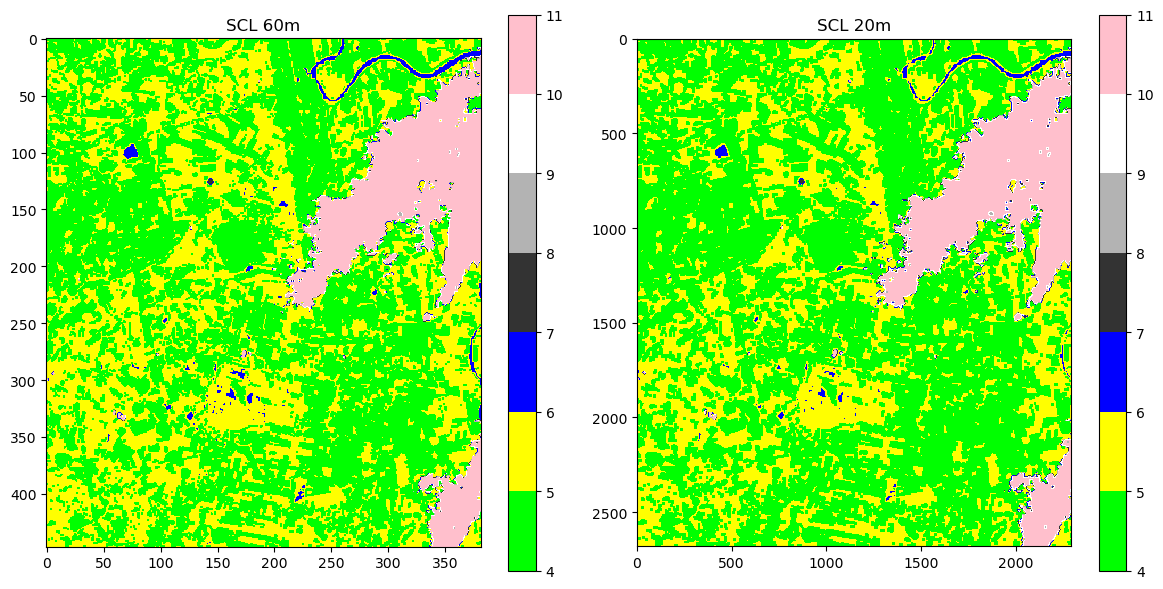

In [24]:
colors = [
    [0, 1, 0, 1],   # Green for 4
    [1, 1, 0, 1],   # Yellow for 5
    [0, 0, 1, 1],   # Blue for 6
    [0.2, 0.2, 0.2, 1], # Dark grey for 7
    [0.7, 0.7, 0.7, 1], # Light grey for 8
    [1, 1, 1, 1],   # White for 9
    [1, 0.75, 0.8, 1]  # Pink for 10
]

# Create a ListedColormap using the specified colors
new_cmap = mcolors.ListedColormap(colors)

# Define the boundaries for the color mapping (4 to 10)
bounds = np.arange(4, 12, 1)

# Create a norm based on the boundaries
norm = mcolors.BoundaryNorm(bounds, new_cmap.N)

SCL_first_band = SCL_resampled[bd]

# Create a figure with two subplots (side by side)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Plot the first image (SCL 60m)
im1 = axs[0].imshow(SCL, cmap=new_cmap, norm=norm)
axs[0].set_aspect('equal')
axs[0].set_title('SCL 60m')
fig.colorbar(im1, ax=axs[0], boundaries=bounds)

# Plot the second image (SCL 20m)
im2 = axs[1].imshow(SCL_first_band, cmap=new_cmap, norm=norm)
axs[1].set_aspect('equal')
axs[1].set_title('SCL 20m')
fig.colorbar(im2, ax=axs[1], boundaries=bounds)

# Show the figure
plt.tight_layout()
plt.show()


In [25]:
# check the data values after regridding
unique_values, counts = np.unique(SCL_resampled, return_counts=True)

# Print the results
print("Unique values:", unique_values)
print("Counts:", counts)

Unique values: [ 2  3  4  5  6  7  8  9 10 11]
Counts: [  11808  378570 3127596 7702044  206700  121212   42558    5904  702756
    5868]


In [26]:
# Check new shape is equal to the other 20m resolution bands
water_pixels[bd].shape

(2682, 2294)

In [27]:
is_cloud.shape

(2682, 2294)

In [1]:
type(is_cloud)

NameError: name 'is_cloud' is not defined

In [28]:
# Apply new cloud mask 
cloud_mask = (is_cloud | shadows) & ~water_pixels[bd]

Text(0.5, 1.0, 'b8 masked no water pixels ')

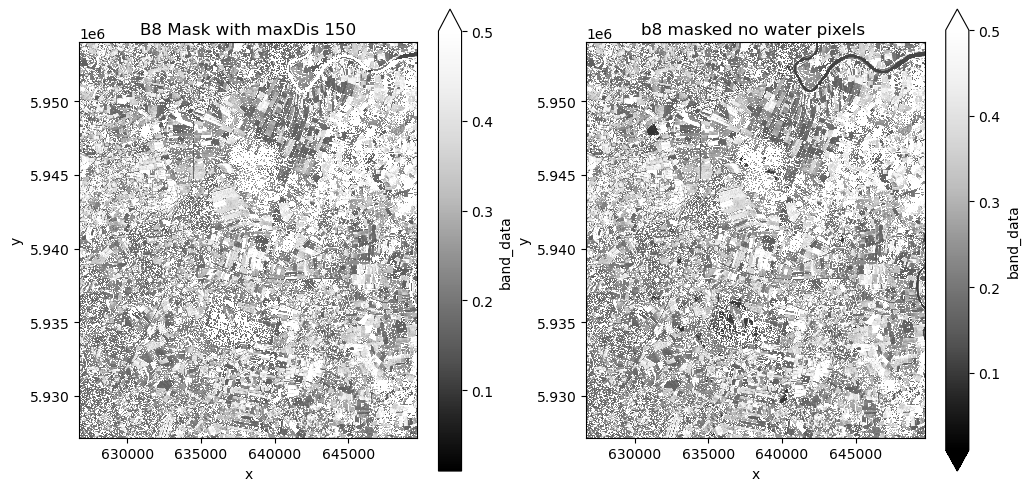

In [29]:
fig_07, (gx, hx) = plt.subplots(1,2, figsize=(12, 6))

b8_masked.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5, ax=gx)
gx.axes.set_aspect('equal')
gx.axes.set_title(f'B8 Mask with maxDis {maxDis}')

b8_masked_nowater = b8.where(~cloud_mask)
b8_masked_nowater.plot.imshow(cmap='Greys_r', vmin=0.01, vmax=0.5, ax=hx)
hx.axes.set_aspect('equal')
hx.axes.set_title(f'b8 masked no water pixels ')